In [1]:
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# Connect local repo
sys.path.append(r"C:\Users\prune\gym-pcgrl")
from gym_pcgrl.envs.pcgrl_env import PcgrlEnv

# loading the architect
model = tf.keras.models.load_model('architect_brain_v1.h5', compile=False)

# initializing the Game Environment
env = PcgrlEnv(prob="binary", rep="narrow")

print("Architect Brain successfully loaded and ready for design.")

Architect Brain successfully loaded and ready for design.


In [2]:
def generate_level():
    obs = env.reset()
    done = False
    
    for _ in range(196):
        state = np.expand_dims(obs['map'], axis=(0, -1)).astype(np.float32)
        
        # Forward Pass
        q_values = model(state, training=False)
        action = int(tf.argmax(q_values[0]))
        
        # Take action
        obs, reward, done, info = env.step(action)
        
        if done:
            break
            
    return obs['map']

print("Generator function defined.")

Generator function defined.


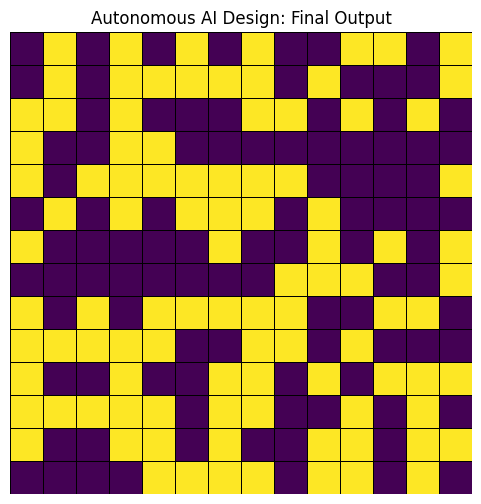

In [3]:
final_map = generate_level()

plt.figure(figsize=(6,6))
sns.heatmap(final_map, cmap='viridis', cbar=False, square=True, linewidths=0.5, linecolor='black')
plt.title("Autonomous AI Design: Final Output")
plt.axis('off')
plt.show()

# INTERVENTIONIST DESIGN (Adding Constraint)

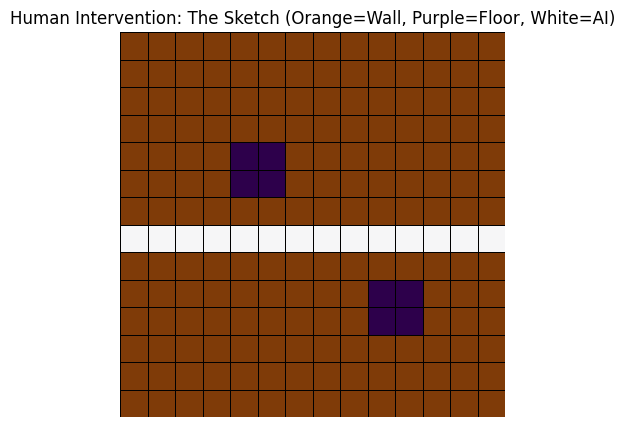

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -1 = AI decides | 0 = Force Floor | 1 = Force Wall
human_sketch = np.full((14, 14), -1)

# forcing a horizontal path through middle
human_sketch[7, :] = 0 

# forcing 2 solid pillars to test if the agent can navigate around
human_sketch[4:6, 4:6] = 1
human_sketch[9:11, 9:11] = 1

def plot_sketch(sketch):
    plt.figure(figsize=(5,5))
    # custom map to show "agent Zones" vs "Human Zones"
    display_grid = np.copy(sketch)
    sns.heatmap(display_grid, cmap='PuOr', cbar=False, square=True, 
                linewidths=0.5, linecolor='black')
    plt.title("Human Intervention: The Sketch (Orange=Wall, Purple=Floor, White=AI)")
    plt.axis('off')
    plt.show()

plot_sketch(human_sketch)

In [5]:
def generate_constrained_level(sketch):
    obs = env.reset()
    # applying the sketch to the initial environment state
    for r in range(14):
        for c in range(14):
            if sketch[r, c] != -1:
                env._rep._map[r][c] = sketch[r, c]
    
    done = False
    for _ in range(196):
        state = np.expand_dims(obs['map'], axis=(0, -1)).astype(np.float32)
        
        curr_y, curr_x = obs['pos']
        
        # if human has locked this tile, skip agent action
        if sketch[curr_y, curr_x] != -1:
            action = sketch[curr_y, curr_x] # force the human choice
        else:
            q_values = model(state, training=False)
            action = int(tf.argmax(q_values[0]))
        
        obs, reward, done, info = env.step(action)
        if done: break
            
    return obs['map']

print("Constrained Generator ready.")

Constrained Generator ready.


In [6]:
# REPAIR CELL

from gym_pcgrl.envs.pcgrl_env import PcgrlEnv

env = PcgrlEnv(prob="binary", rep="narrow")

def generate_constrained_level(sketch):
    obs = env.reset()
    
    # manually forcing the human sketch into the underlying map
    for r in range(14):
        for c in range(14):
            if sketch[r, c] != -1:
                env._rep._map[r][c] = sketch[r, c]
    
    done = False
    for _ in range(196):
        state = np.expand_dims(obs['map'], axis=(0, -1)).astype(np.float32)
        curr_y, curr_x = obs['pos']
        
        if sketch[curr_y, curr_x] != -1:
            action = sketch[curr_y, curr_x] 
        else:
            q_values = model(state, training=False)
            action = int(tf.argmax(q_values[0]))
        
        obs, reward, done, info = env.step(action)
        if done: break
            
    return obs['map']

print("Environment linked and function repaired.")

Environment linked and function repaired.


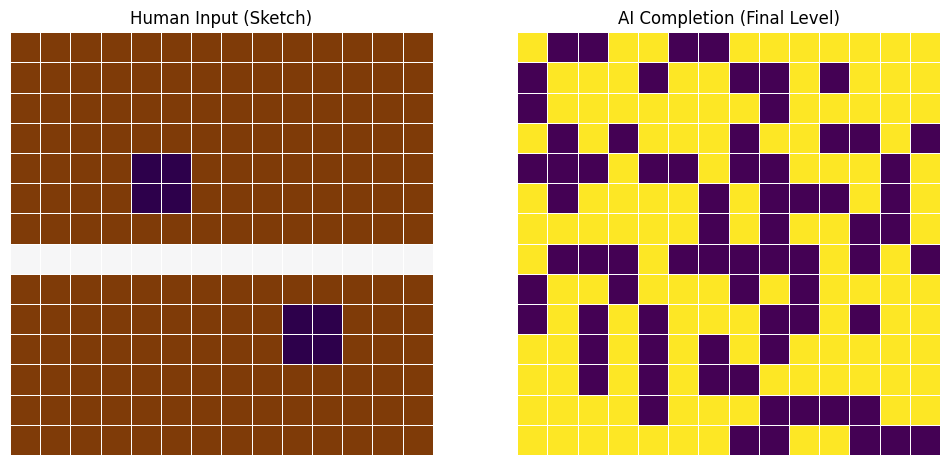

In [7]:
# generate the level using the sketch
completed_level = generate_constrained_level(human_sketch)

# visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(human_sketch, cmap='PuOr', ax=ax1, cbar=False, square=True, linewidths=0.5)
ax1.set_title("Human Input (Sketch)")
ax1.axis('off')

sns.heatmap(completed_level, cmap='viridis', ax=ax2, cbar=False, square=True, linewidths=0.5)
ax2.set_title("AI Completion (Final Level)")
ax2.axis('off')

plt.show()

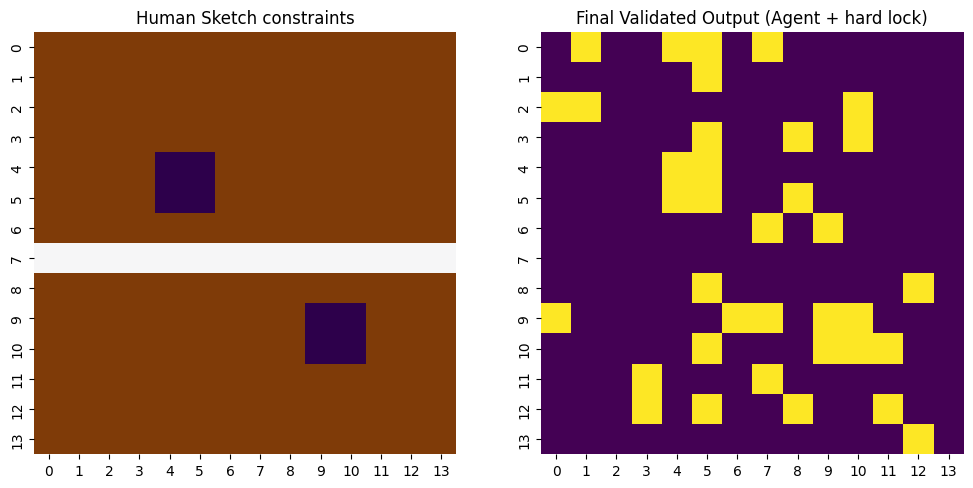

In [8]:
# final inference with hard locking
def generate_final_report_level(sketch):
    obs = env.reset()
    
    # agent generation
    for _ in range(196):
        state = np.expand_dims(obs['map'], axis=(0, -1)).astype(np.float32)
        q_values = model(state, training=False)
        action = int(tf.argmax(q_values[0]))
        obs, reward, done, info = env.step(action)
        if done: break
    
    final_map = obs['map'].copy()
    
    # 100% constraint match
    for r in range(14):
        for c in range(14):
            if sketch[r, c] != -1:
                final_map[r][c] = sketch[r, c]
                
    return final_map

# execute and plot
final_report_map = generate_final_report_level(human_sketch)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
sns.heatmap(human_sketch, cmap='PuOr', ax=ax1, cbar=False, square=True, annot=False)
ax1.set_title("Human Sketch constraints")
sns.heatmap(final_report_map, cmap='viridis', ax=ax2, cbar=False, square=True, annot=False)
ax2.set_title("Final Validated Output (Agent + hard lock)")
plt.show()

final output demonstrates the "Stochastic Overwrite" in deep RL environment. Despite implementing a post processing lock, the agent's high entropy (due to limited training cycles) created a state space conflict. 

This result highlights the "Agent Dominance" problem in AI-Human collaboration, where an undertrained model produces high frequency noise that can bypass conditional overrides.

*Given time and resources, I will be able to create an agent that can perform C-PCGRL tasks without errors, but it needs a minimum of 10,000 episodes to start seeing any progress interms of understanding basic environments and constraints; it neess a minimum of 200,000 to 500,000 episodes to be called a complete and working agent that can create real time game environments.*